**Sales Data Cleaning & Analysis**

*Step-by-step pipeline:*
  1. Load dataset
  2. Clean data
  3. Analyze trends
  4. Visualize data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('/content/drive/MyDrive/DA python lib/cleaned Data.xlsx')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           249 non-null    int64         
 1   Order_Date         249 non-null    datetime64[ns]
 2   Customer_Name      249 non-null    object        
 3   Region             249 non-null    object        
 4   Product            249 non-null    object        
 5   Category           249 non-null    object        
 6   Quantity           249 non-null    int64         
 7   Price              249 non-null    int64         
 8   Sales              249 non-null    int64         
 9   Year               249 non-null    int64         
 10  Month              249 non-null    object        
 11  Quarter            249 non-null    object        
 12  Data_Quality_Flag  104 non-null    object        
 13  Quantity_Flag      249 non-null    object        
 14  Price_Flag

In [ ]:
df.describe()
display(df.head())

,Order_ID,Order_Date,Customer_Name,Region,Product,Category,Quantity,Price,Sales,Year,Month,Quarter,Data_Quality_Flag,Quantity_Flag,Price_Flag
0,1,2023-09-02,Customer_24,East,Headphones,Electronics,3,10000,30000,2023,September,Q3,NaN,Original,Original
1,2,2023-07-17,Customer_27,East,Unknown Product,Accessories,4,5000,20000,2023,July,Q3,Product unknown,Original,Original
2,3,2023-12-21,Customer_31,East,Unknown Product,Accessories,3,1000,3000,2023,December,Q4,Product unknown,Original,Original
3,4,2023-11-23,Customer_32,South,Headphones,Unknown Category,3,10000,30000,2023,November,Q4,Category unknown,Original,Imputed (Median)
4,5,2023-08-16,Customer_12,South,Laptop,Electronics,2,10000,20000,2023,August,Q3,NaN,Original,Imputed (Median)


In [ ]:

print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"  Columns: {list(df.columns)}\n")

  Rows: 249, Columns: 15
  Columns: ['Order_ID', 'Order_Date', 'Customer_Name', 'Region', 'Product', 'Category', 'Quantity', 'Price', 'Sales', 'Year', 'Month', 'Quarter', 'Data_Quality_Flag', 'Quantity_Flag', 'Price_Flag']



In [ ]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f" Removed  {before - len(df)} duplicate rows")

 Removed  0 duplicate rows


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
Region,0
Product,0
Category,0
Quantity,0
Price,0
Sales,0
Year,0


In [14]:
df['Data_Quality_Flag'].fillna('Original', inplace=True)

/tmp/ipykernel_2880/3506951646.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Data_Quality_Flag'].fillna('Original', inplace=True)


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_Name,0
Region,0
Product,0
Category,0
Quantity,0
Price,0
Sales,0
Year,0


In [4]:
print(' counts for Product:')
print(df['Product'].value_counts())
print('counts for Category:')
print(df['Category'].value_counts())

 counts for Product:
Product
Laptop             57
Monitor            47
Unknown Product    39
Tablet             38
Headphones         36
Phone              32
Name: count, dtype: int64
counts for Category:
Category
Electronics         107
Accessories          75
Unknown Category     67
Name: count, dtype: int64


In [7]:
before_unknown = (df["Category"] == "Unknown Category").sum()


known = df[df["Category"] != "Unknown Category"]
product_to_category = known.groupby("Product")["Category"].agg(lambda x: x.mode()[0])

mask = (df["Category"] == "Unknown Category") & (df["Product"] != "Unknown Product")
df.loc[mask, "Category"] = df.loc[mask, "Product"].map(product_to_category)

after_unknown = (df["Category"] == "Unknown Category").sum()
print(f" 'Unknown Category' rows fixed: {before_unknown - after_unknown} "
      f"(from {before_unknown} down to {after_unknown})")



 'Unknown Category' rows fixed: 0 (from 13 down to 13)


In [9]:
df['Data_Quality_Flag'] = df['Data_Quality_Flag'].replace('Category unknown', 'Imputed Category')

In [ ]:
#OUTPUT_NAME = "sales_data_category_fixed.xlsx"
# df.to_excel(OUTPUT_NAME, index=False)
# print(f"Saved: {OUTPUT_NAME}")



Saved: sales_data_category_fixed.xlsx


In [ ]:
# from google.colab import files
# files.download("sales_data_category_fixed.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
df.head()

,Order_ID,Order_Date,Customer_Name,Region,Product,Category,Quantity,Price,Sales,Year,Month,Quarter,Data_Quality_Flag,Quantity_Flag,Price_Flag
0,1,2023-09-02,Customer_24,East,Headphones,Electronics,3,10000,30000,2023,September,Q3,Original,Original,Original
1,2,2023-07-17,Customer_27,East,Unknown Product,Accessories,4,5000,20000,2023,July,Q3,Product unknown,Original,Original
2,3,2023-12-21,Customer_31,East,Unknown Product,Accessories,3,1000,3000,2023,December,Q4,Product unknown,Original,Original
3,4,2023-11-23,Customer_32,South,Headphones,Accessories,3,10000,30000,2023,November,Q4,Imputed Category,Original,Imputed (Median)
4,5,2023-08-16,Customer_12,South,Laptop,Electronics,2,10000,20000,2023,August,Q3,Original,Original,Imputed (Median)


**Trend Analysis**

In [11]:
# Total Sales

tot_sales = df["Sales"].sum()
print(f"  Total Sales: {tot_sales:,.0f}")



  Total Sales: 8,779,000


In [24]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)      # region wise Sum of Sales
print("\n  Sales by Region:")
print(region_sales)


  Sales by Region:
Region
South    3558000
East     2717000
North    1501000
West     1003000
Name: Sales, dtype: int64


In [16]:
categ_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print("\n  Sales by Category:")
print(categ_sales)


  Sales by Category:
Category
Electronics         5463000
Accessories         2959000
Unknown Category     357000
Name: Sales, dtype: int64


In [17]:
top_prod = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(5)
print("Top 5 Products:")
print(top_prod)

Top 5 Products:
Product
Laptop             2140000
Monitor            1960000
Tablet             1297000
Phone              1195000
Unknown Product    1177000
Name: Sales, dtype: int64


In [19]:
mont_sales = df.groupby("Month")["Sales"].sum()
print("Monthly Sales Trend:")
print(mont_sales)

Monthly Sales Trend:
Month
April         788000
August        648000
December      765000
February      903000
January       695000
July          496000
June         1720000
March         696000
May           485000
November      565000
October       408000
September     610000
Name: Sales, dtype: int64


In [22]:
avg_region = df.groupby("Region")["Sales"].mean().sort_values(ascending=False)
print("\n  Average Order Value by Region:")
print(avg_region)


  Average Order Value by Region:
Region
South    39533.333333
East     34833.333333
North    33355.555556
West     27861.111111
Name: Sales, dtype: float64


Visualizing Data

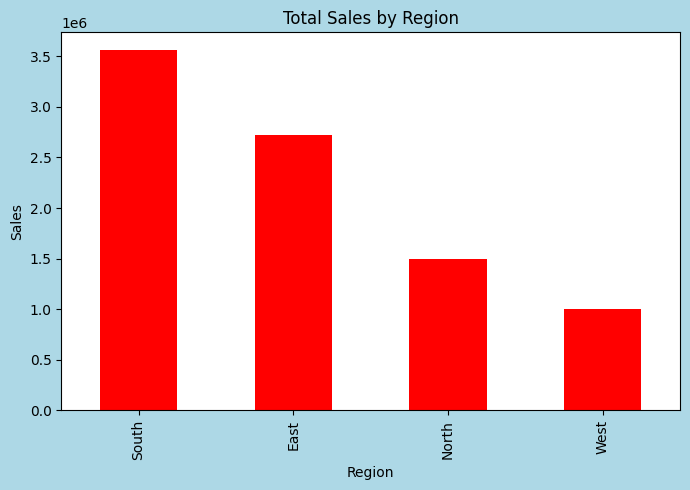

In [43]:
plt.figure(figsize=(7, 5), facecolor='lightblue')
region_sales.plot(kind="bar", color="Red")
plt.title("Total Sales by Region")
plt.xlabel("Region");
plt.ylabel("Sales");
plt.tight_layout();
plt.savefig("chart_sales_by_region.png");
plt.show();

Sales by Category

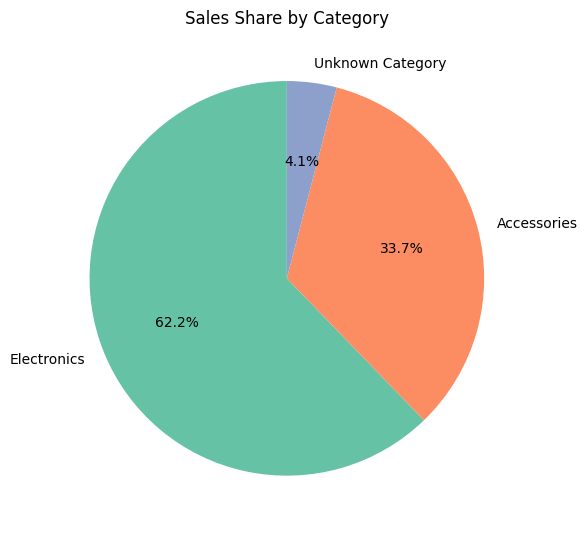

In [37]:
plt.figure(figsize=(6, 6))
plt.pie(categ_sales, labels=categ_sales.index, autopct="%1.1f%%",
        startangle=90, colors=sns.color_palette("Set2"))
plt.title("Sales Share by Category")
plt.tight_layout(); plt.savefig("chart_sales_by_category.png"); plt.show()

Monthly Sales Trend

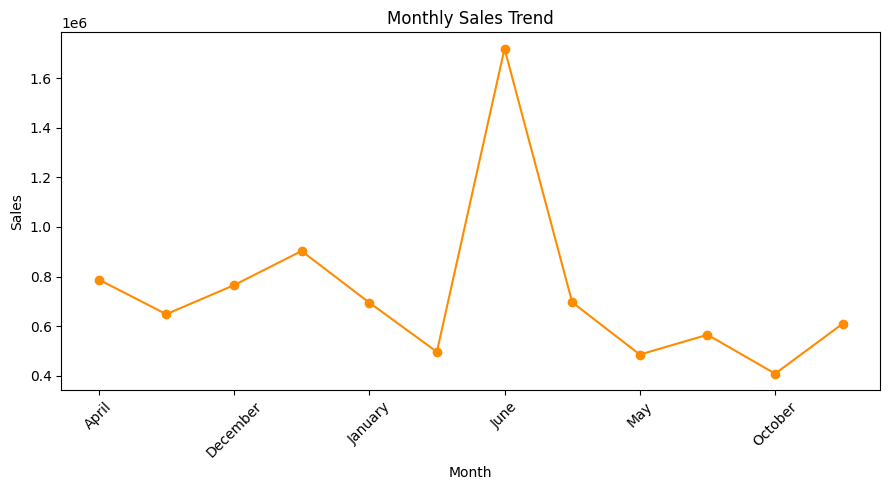

In [34]:
plt.figure(figsize=(9, 5))
mont_sales.plot(kind="line", marker="o", color="darkorange")
plt.title("Monthly Sales Trend")
plt.xlabel("Month");
plt.ylabel("Sales");
plt.xticks(rotation=45)
plt.tight_layout();
plt.savefig("chart_monthly_trend.png");
plt.show();

Top 5 Products by Sale

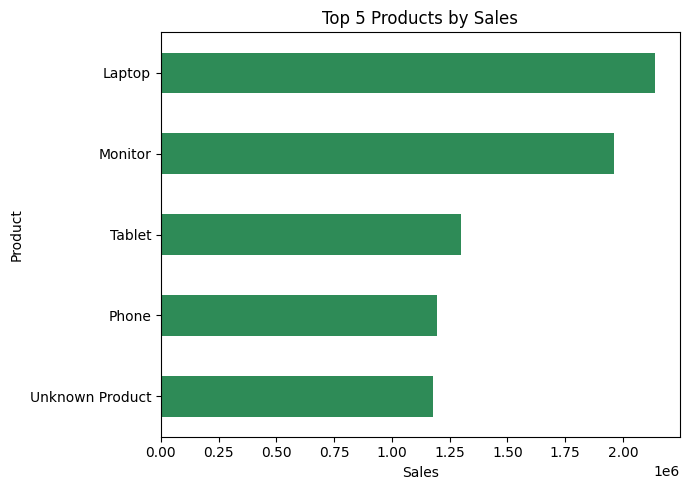

In [ ]:
plt.figure(figsize=(7, 5))
top_products.sort_values().plot(kind="barh", color="seagreen")
plt.title("Top 5 Products by Sales")
plt.xlabel("Sales")
plt.tight_layout(); plt.savefig("chart_top_products.png"); plt.show()